In [1]:
import pandas as pd

train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

train.shape, test.shape
train.dtypes.value_counts()
train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [2]:
train.isnull().sum().sort_values(ascending=False).head(20)
train.isnull().mean().sort_values(ascending=False).head(20) * 100

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtCond         2.534247
BsmtQual         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
Condition2       0.000000
dtype: float64

<Axes: >

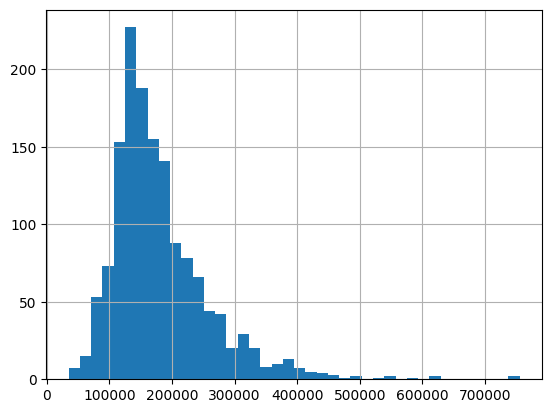

In [3]:

train['SalePrice'].skew()
train['SalePrice'].hist(bins=40)

In [4]:
num_cols = train.select_dtypes(include=['int64','float64']).columns
cat_cols = train.select_dtypes(include=['object']).columns
len(num_cols), len(cat_cols)

C:\Users\om.ak\AppData\Local\Temp\ipykernel_10020\742321652.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include=['object']).columns


(38, 43)

In [5]:
train[num_cols].corr()['SalePrice'].sort_values(ascending=False).head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

In [6]:
train.duplicated().sum()

np.int64(0)

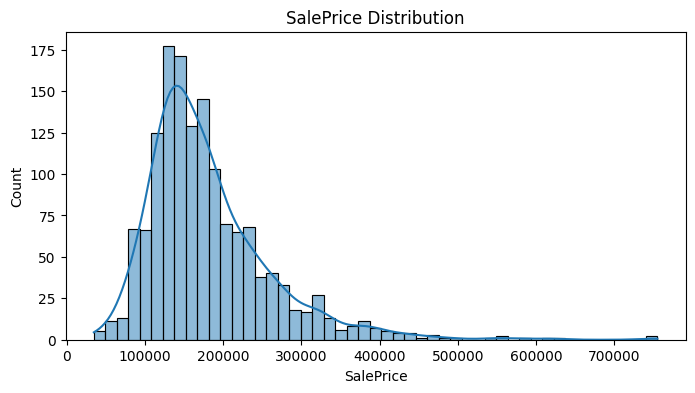

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(train['SalePrice'], kde=True)
plt.title('SalePrice Distribution')
plt.savefig('../images/saleprice_dist.png')
plt.show()

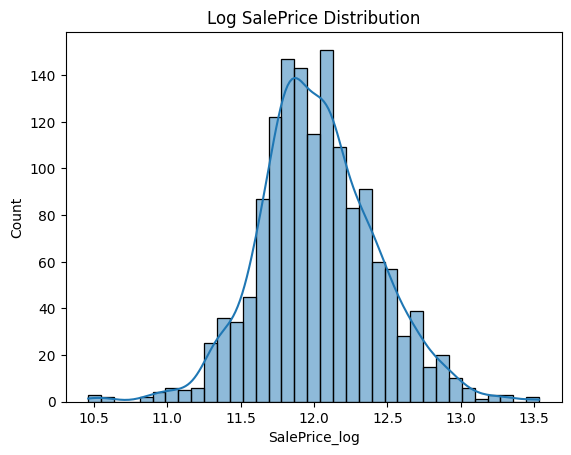

In [8]:
import numpy as np
train['SalePrice_log'] = np.log1p(train['SalePrice'])
sns.histplot(train['SalePrice_log'], kde=True)
plt.title('Log SalePrice Distribution')
plt.savefig('../images/saleprice_log_dist.png')
plt.show()

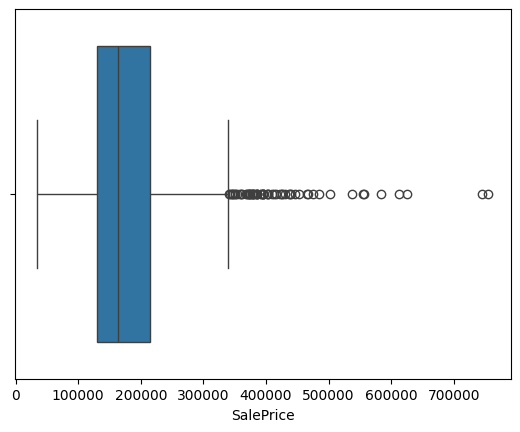

In [9]:
sns.boxplot(x=train['SalePrice'])
plt.savefig('../images/saleprice_boxplot.png')
plt.show()

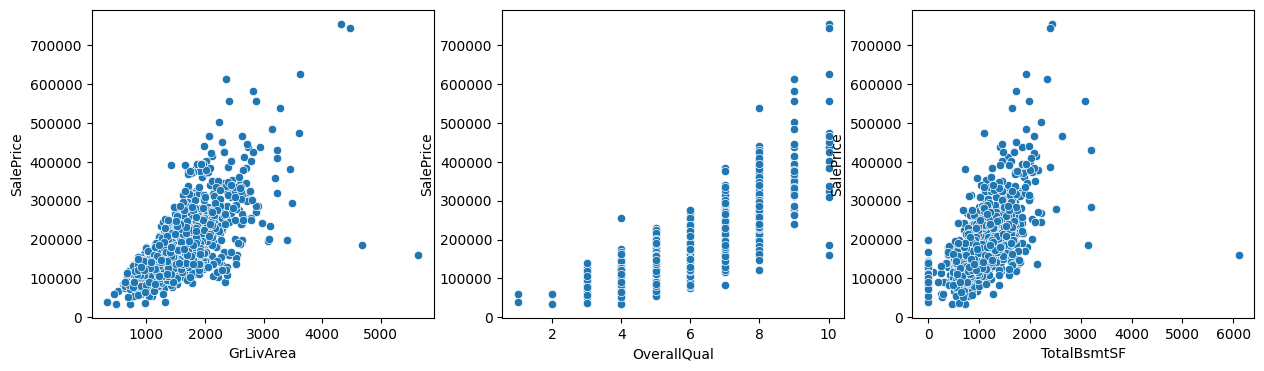

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'], ax=axes[0])
sns.scatterplot(x=train['OverallQual'], y=train['SalePrice'], ax=axes[1])
sns.scatterplot(x=train['TotalBsmtSF'], y=train['SalePrice'], ax=axes[2])
plt.savefig('../images/scatter_features.png')
plt.show()

In [11]:
train = train[~((train['GrLivArea']>4000) & (train['SalePrice']<300000))]
train.shape

(1458, 82)

In [12]:
none_cols = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
             'GarageType','GarageFinish','GarageQual','GarageCond',
             'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
             'MasVnrType']
for col in none_cols:
    train[col] = train[col].fillna('None')

In [13]:
zero_cols = ['GarageYrBlt','GarageArea','GarageCars','MasVnrArea',
             'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
             'BsmtFullBath','BsmtHalfBath']
for col in zero_cols:
    train[col] = train[col].fillna(0)

In [14]:
train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage']\
                             .transform(lambda x: x.fillna(x.median()))

In [15]:
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

In [16]:
train.isnull().sum().sum()

np.int64(0)

In [17]:
for col in none_cols:
    test[col] = test[col].fillna('None')
for col in zero_cols:
    test[col] = test[col].fillna(0)
test['LotFrontage'] = test.groupby('Neighborhood')['LotFrontage']\
                           .transform(lambda x: x.fillna(x.median()))
test['Electrical'] = test['Electrical'].fillna(test['Electrical'].mode()[0])

test.isnull().sum().sum()

np.int64(12)

In [18]:
for col in train.columns:
    if train[col].isnull().sum() > 0:
        if train[col].dtype == 'object':
            train[col] = train[col].fillna(train[col].mode()[0])
        else:
            train[col] = train[col].fillna(train[col].median())

train.isnull().sum().sum()

np.int64(0)

In [19]:
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
train['HouseAge'] = train['YrSold'] - train['YearBuilt']
train['RemodAge'] = train['YrSold'] - train['YearRemodAdd']
train['TotalBath'] = train['FullBath'] + 0.5*train['HalfBath'] + \
                      train['BsmtFullBath'] + 0.5*train['BsmtHalfBath']

In [20]:
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']
test['HouseAge'] = test['YrSold'] - test['YearBuilt']
test['RemodAge'] = test['YrSold'] - test['YearRemodAdd']
test['TotalBath'] = test['FullBath'] + 0.5*test['HalfBath'] + \
                     test['BsmtFullBath'] + 0.5*test['BsmtHalfBath']

In [21]:
train[['TotalSF','HouseAge','RemodAge','TotalBath','SalePrice']].corr()['SalePrice']

TotalSF      0.832877
HouseAge    -0.524067
RemodAge    -0.509706
TotalBath    0.635896
SalePrice    1.000000
Name: SalePrice, dtype: float64

In [22]:
train_encoded = pd.get_dummies(train.drop(['Id','SalePrice','SalePrice_log'], axis=1))
test_encoded = pd.get_dummies(test.drop('Id', axis=1))

# Align columns (train/test ma same columns hunu parxa)
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

train_encoded.shape, test_encoded.shape

((1458, 305), (1459, 305))

In [23]:
X = train_encoded
y = train['SalePrice_log']   # log target use garne - better model performance dincha

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_val.shape

((1166, 305), (292, 305))

In [25]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=10),
    'Lasso': Lasso(alpha=0.001),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    # log scale bata original price scale ma convert
    preds_actual = np.expm1(preds)
    y_val_actual = np.expm1(y_val)
    
    mae = mean_absolute_error(y_val_actual, preds_actual)
    rmse = np.sqrt(mean_squared_error(y_val_actual, preds_actual))
    r2 = r2_score(y_val_actual, preds_actual)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

results_df = pd.DataFrame(results).T
results_df.sort_values('R2', ascending=False)

c:\Users\om.ak\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.882911e+00, tolerance: 1.836e-02
  model = cd_fast.enet_coordinate_descent(


,MAE,RMSE,R2
Gradient Boosting,13643.190598,19069.565857,0.934166
Lasso,14020.609964,19508.156300,0.931103
Ridge,14514.734494,20047.975290,0.927237
Linear Regression,15356.713372,21762.036351,0.914263
Random Forest,16338.529599,23451.889075,0.900431


In [27]:
from sklearn.model_selection import cross_val_score

gb = GradientBoostingRegressor(random_state=42)
cv_scores = cross_val_score(gb, X, y, cv=5, scoring='r2')
cv_scores, cv_scores.mean()

(array([0.91644794, 0.91083818, 0.89886764, 0.91468531, 0.90034403]),
 np.float64(0.9082366208903692))

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}

grid = GridSearchCV(GradientBoostingRegressor(random_state=42),
                     param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

grid.best_params_, grid.best_score_

({'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300},
 np.float64(0.9039077715481076))

In [29]:
best_model = grid.best_estimator_
preds = best_model.predict(X_val)

preds_actual = np.expm1(preds)
y_val_actual = np.expm1(y_val)

mae = mean_absolute_error(y_val_actual, preds_actual)
rmse = np.sqrt(mean_squared_error(y_val_actual, preds_actual))
r2 = r2_score(y_val_actual, preds_actual)

mae, rmse, r2

(13910.142794680723, np.float64(19407.16982872248), 0.9318144766527454)

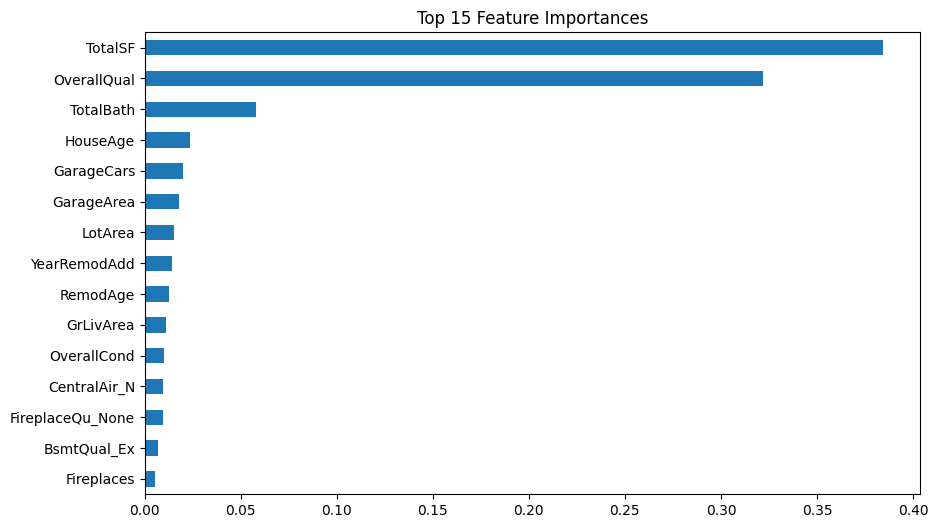

In [30]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
top_features.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances')
plt.savefig('../images/feature_importance.png')
plt.show()

In [31]:
top_features

TotalSF             0.384361
OverallQual         0.322133
TotalBath           0.058095
HouseAge            0.023654
GarageCars          0.019803
GarageArea          0.017635
LotArea             0.014972
YearRemodAdd        0.013881
RemodAge            0.012551
GrLivArea           0.010923
OverallCond         0.010187
CentralAir_N        0.009407
FireplaceQu_None    0.009358
BsmtQual_Ex         0.007067
Fireplaces          0.005190
dtype: float64

In [32]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/house_price_model.pkl')
joblib.dump(X.columns.tolist(), '../models/model_columns.pkl')

print("Model saved!")

Model saved!
